# Part2: Cell subtype identification of malignant cells in the HGSC dataset

# Package loading and path setting

In [1]:
import sys
working_dir = "D:/CellFlowMap/SpiderNet_proj/SpiderNet_proj/"
sys.path.append("working_dir")
##Package import
import os
import scanpy as sc
import seaborn as sns
from SpiderNet.model import *
from SpiderNet.utils import *
from scipy.stats import ranksums
cuda_available = torch.cuda.is_available()
if cuda_available:
    # num_gpus = torch.cuda.device_count()
    # print(f"Number of GPUs available: {num_gpus}")
    # for i in range(num_gpus):
    #     print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
    ##
    device = "cuda"
else:
    # print("No GPU available, using CPU instead.")
    device = "cpu"

D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\_utils\__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


Number of GPUs available: 1
GPU 0: NVIDIA GeForce RTX 4070


# Hyperparameter Setup

In [2]:

# Version
Version_cur = "V1"

# Factorization mode
Factor_mode = 'cell_class'  # options: 'cell_class', 'NMF'
dim_intri = 25 if Factor_mode == "NMF" else None

# Environmental dimension
dim_envir = 15   # examples: 8, 10, 12, 20, 30, None

# Meta-interaction aggregation threshold
MIlevel_agg_threshold = 0.6     # typical range: 0.4–0.7


# File Path Setup

In [3]:
# Base directories
data_path_main = "D:/CellFlowMap/HGSC/Data/"
save_path_main = data_path_main.replace("Data/", "Results/")

# Current run directory (versioned)
data_path_main_cur = data_path_main
save_path_main_cur = os.path.join(save_path_main, Version_cur)
os.makedirs(save_path_main_cur, exist_ok=True)

# Define subdirectory name pattern
subset_tag = ""
result_tag = f"SpiderNet_Result_Mode_{Factor_mode}_selfsetdim{dim_envir}{subset_tag}"

# Define output paths
file_savepath_main = os.path.join(save_path_main_cur, result_tag)
if not file_savepath_main.endswith(os.sep):
    file_savepath_main += os.sep


# Load the data

## Load the processed SpiderNet data

In [4]:
adata_copy_path = file_savepath_main + "adata_all.h5ad"
adata_copy = sc.read_h5ad(adata_copy_path, backed='r')
SpiderNet_data_pyg_list = pd.read_pickle(file_savepath_main + 'SpiderNet_data_pyg_list.pkl')
metadata_sample_path = file_savepath_main + "metadata_sample.csv"
metadata_sample = pd.read_csv(metadata_sample_path)
LR_list = pd.read_pickle(file_savepath_main + 'LR_list.pkl')
batch_cell_unique = pd.read_pickle(file_savepath_main + 'batch_cell_unique.pkl')
genenames_train = pd.read_pickle(file_savepath_main + 'genenames_train.pkl')
LR_list_cellchatdb = pd.read_pickle(file_savepath_main + 'LR_list_cellchatdb.pkl')
LR_meta_cellchatdb = pd.read_pickle(file_savepath_main + 'LR_meta_cellchatdb.pkl')
batch_cell_path = file_savepath_main + 'batch_cell.pkl'
batch_cell = pd.read_pickle(batch_cell_path)
adata_list_path = file_savepath_main + 'adata_list.pkl'
adata_list = pd.read_pickle(adata_list_path)
LR_loading_pathway_show_pathway = file_savepath_main + "LR_loading_pathway_show.csv"


## Move data to device

In [5]:
for batch_cell_unique_cur_index in range(len(batch_cell_unique)):
    SpiderNet_data_pyg_list[batch_cell_unique_cur_index] = SpiderNet_data_pyg_list[batch_cell_unique_cur_index].to(device)


# Use the Meta-interaction to guide the cell subtype identification

In [6]:
##Specify the cell class to analyze
cellclass_choose = 'Malignant'
cellclass_choose_show = cellclass_choose.replace(".","_")

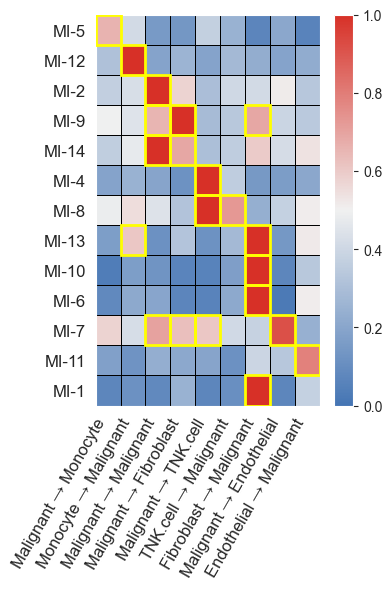

E:\ANACONDA\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ Finished embedding for Malignant. Results saved in D:/CellFlowMap/HGSC/Results/V1\SpiderNet_Result_Mode_cell_class_selfsetdim15\.


In [7]:
from SpiderNet.MI_induced_embedding import run_analysis

run_analysis(
    cellclass_choose=cellclass_choose,
    file_savepath_main=file_savepath_main,
    Factor_envir_list_path=file_savepath_main + "Factor_envir_list.pkl",
    adata_copy_path= file_savepath_main + "adata_all.h5ad",
    device=device,
    SpiderNet_data_pyg_list_path= file_savepath_main + 'SpiderNet_data_pyg_list.pkl',
    LR_list_merge_path=file_savepath_main + 'LR_list_merge.pkl',
    Avg_MI_cellclass_pair_merge_use_path=file_savepath_main + "Avg_MI_cellclass_pair_merge_use.pkl",
    dim_envir=dim_envir,
    MIlevel_agg_threshold=MIlevel_agg_threshold,
    metadata_sample_path=file_savepath_main + "metadata_sample.csv",
    embedding_method="PCA",
    show=True
)


In [8]:
adata_choose_path = file_savepath_main + "adata_choose_" + str(cellclass_choose) + ".h5ad"

In [9]:
##load the adata_choose
adata_choose = sc.read_h5ad(adata_choose_path)

In [10]:
adata_choose

AnnData object with n_obs × n_vars = 203476 × 979
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'samples', 'patients_x', 'sites_binary_x', 'cell.types', 'cell.subtypes', 'x', 'y', 'sample_name', 'B.cell_prop', 'Endothelial_prop', 'Fibroblast_prop', 'Malignant_prop', 'Mast.cell_prop', 'Monocyte_prop', 'TNK.cell_prop', 'barcode', 'platform', 'n_cells', 'median_tpc', 'mean_tpc', 'TMA', 'patients_y', 'sites_binary_y', 'age', 'stage', 'treatment', '1L', 'parpi', 'immunotherapy', 'fu_time1', 'fu_time2', 'outcome', 'pfs', 'BRCA1_Somatic', 'BRCA2_Somatic', 'TP53_Somatic', 'BRCA1_Germline', 'BRCA2_Germline', 'TP53_Germline', 'tmb', 'stage_index', 'treatment_index', 'sites_binary_index', 'outcome_use', 'outcome_use_index'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'
    obsm: 'MI_PCA', 'MI_UMAP', 'spatial'
    layers: 'counts', 'data', 'scale.data'

## Show the feature on Umap of adata_choose

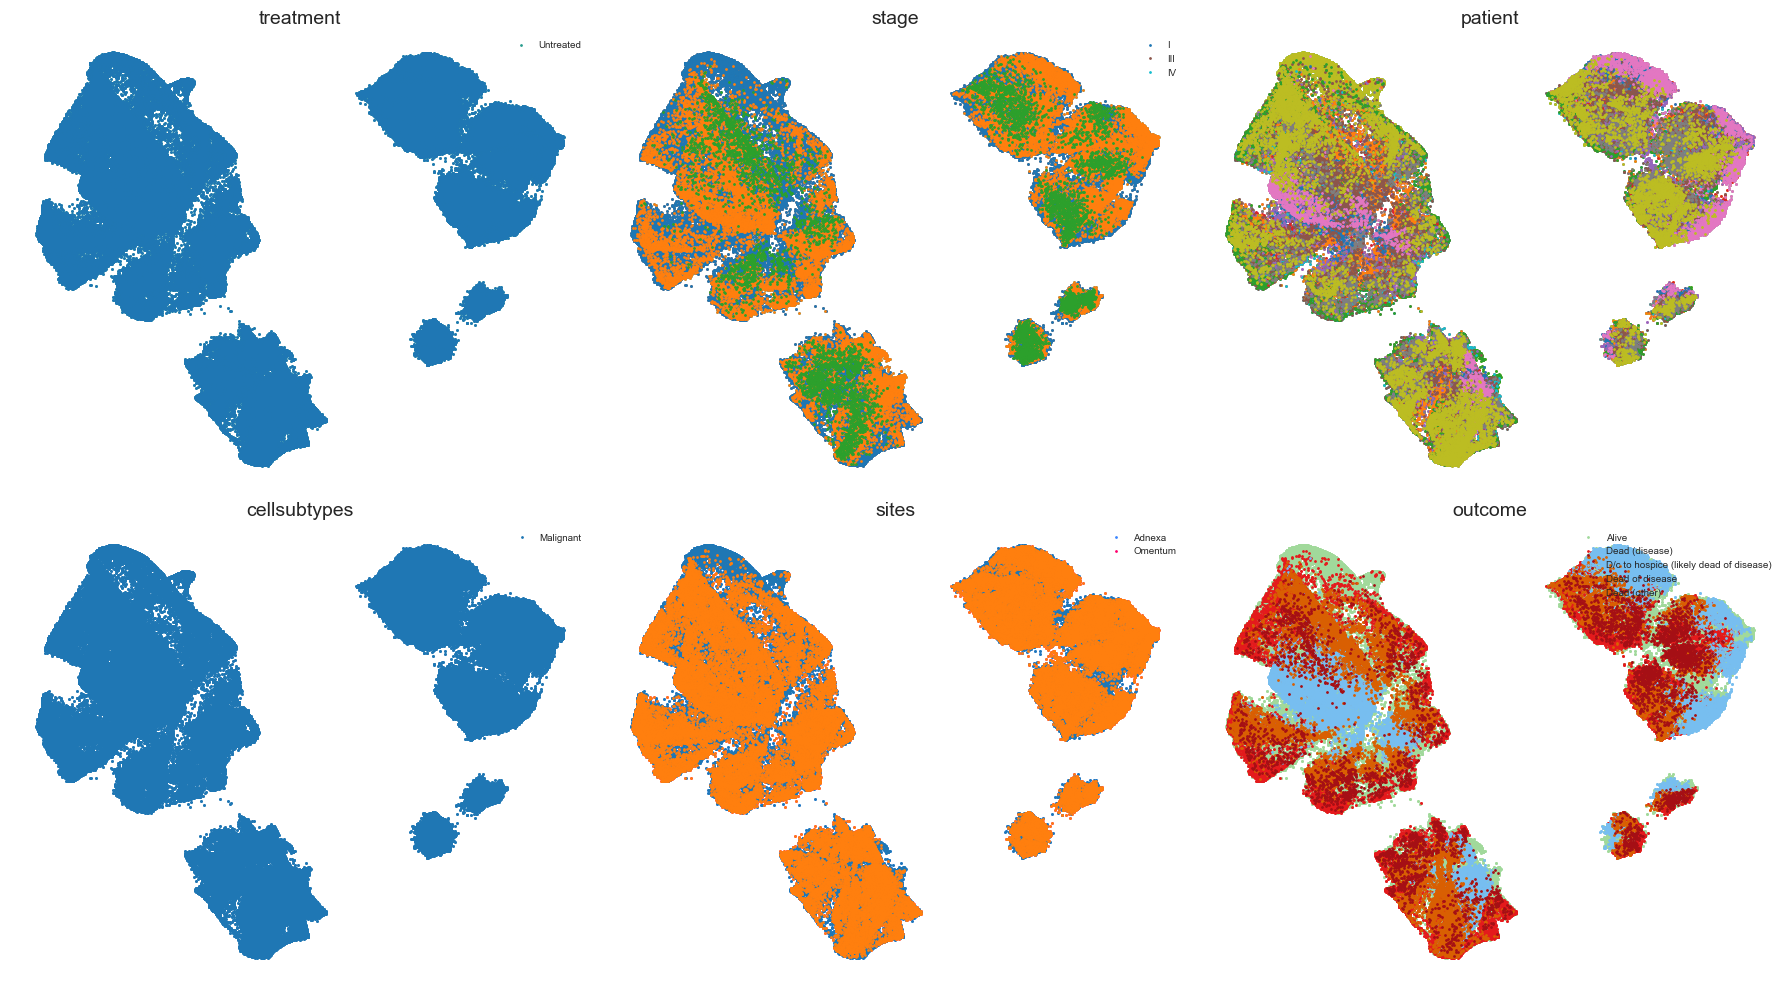

✅ All annotation (shown) and neighboring-cell (saved) UMAP plots written to D:/CellFlowMap/HGSC/Results/V1\SpiderNet_Result_Mode_cell_class_selfsetdim15\


In [11]:
from SpiderNet.Feature_show_umap import run_feature_umap

run_feature_umap(
    cellclass_choose=cellclass_choose,
    adata_choose_path=file_savepath_main + f"adata_choose_{cellclass_choose}.h5ad",
    file_savepath_main=file_savepath_main,
    obsm_show="MI_UMAP",
    adata_copy_path=file_savepath_main + "adata_all.h5ad",
    show=True
)


## Louvain clustering on the MI embedding

In [12]:
adata_choose = sc.read_h5ad(adata_choose_path)
#
sc.pp.neighbors(adata_choose, use_rep='MI_PCA', n_neighbors=20)
#
sc.tl.louvain(adata_choose, resolution=0.17, key_added='MI_louvain')

D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\neighbors\__init__.py:427: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


In [13]:
# Assign MI_louvain clusters to adata_choose
cluster_assign = adata_choose.obs["MI_louvain"]

# Save cluster assignments
cluster_assign.to_csv(f"{file_savepath_main}Cluster_assignment_{cellclass_choose}.csv")

# Create a barcode-indexed version
cluster_assign_df = pd.DataFrame({
    "MI_louvain": cluster_assign.values
}, index=adata_choose.obs["barcode"].tolist())
cluster_assign_df["MI_louvain_C"] = "C" + (cluster_assign_df["MI_louvain"].astype(int) + 1).astype(str)

# Save barcode-based cluster assignments
cluster_assign_df.to_csv(f"{file_savepath_main}Cluster_assignment_{cellclass_choose}_barcode.csv")

# Print number of clusters
print(f"Number of clusters identified in {cellclass_choose}: {cluster_assign.nunique()}")

# Save updated AnnData object
adata_choose.write_h5ad(adata_choose_path)


Number of clusters identified in Malignant: 6


In [14]:
##Add 1 to the cluster number
adata_choose.obs['MI_louvain'] = (adata_choose.obs['MI_louvain'].astype(int) + 1).astype(str)

In [15]:
adata_choose_path

'D:/CellFlowMap/HGSC/Results/V1\\SpiderNet_Result_Mode_cell_class_selfsetdim15\\adata_choose_Malignant.h5ad'

### Show UMAP of MI_louvain clustering

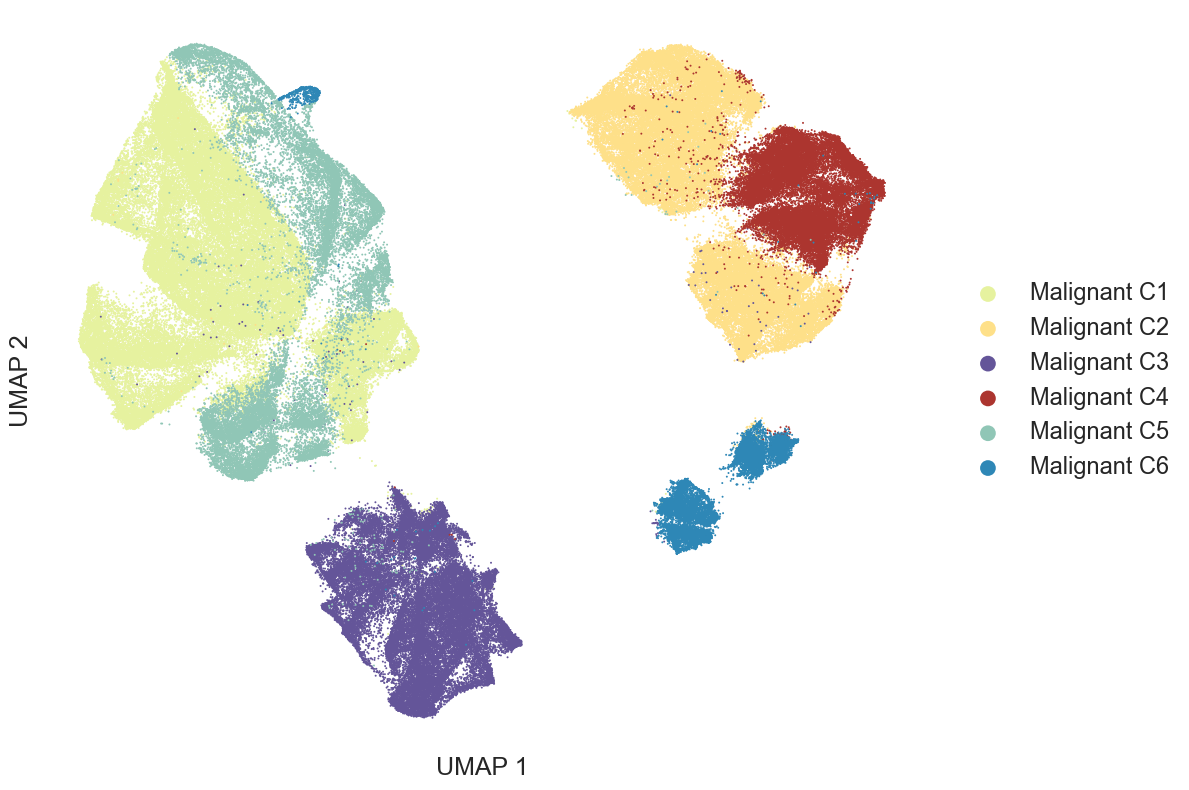

In [16]:
import matplotlib.pyplot as plt

plt.close()
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Prepare cluster info
subtype_cat = adata_choose.obs["MI_louvain"].astype("category")
subtype_codes = subtype_cat.cat.codes
subtype_names = subtype_cat.cat.categories
n_subtypes = len(subtype_names)

# Custom color palette
custom_colors = [
    "#e6f29f", "#d6e97c",
    "#fee089", "#f6b656",
    "#645599", "#8c6bb1",
    "#ac352f", "#d95f02",
    "#90c6b6", "#64b3a9",
    "#2e87b6", "#1b5f8a"
]

# Use every second color (1st, 3rd, 5th...)
base_colors = custom_colors[::2]
colors = [base_colors[i % len(base_colors)] for i in range(n_subtypes)]

# Plot UMAP clusters
for i, name in enumerate(subtype_names):
    idx = (subtype_codes == i)
    ax.scatter(
        adata_choose.obsm["MI_UMAP"][idx, 0],
        adata_choose.obsm["MI_UMAP"][idx, 1],
        c=[colors[i]], s=2, edgecolor="none",
        label=f"{cellclass_choose} C{i + 1}"   # ✅ increment cluster number by 1
    )

# Axis labels
ax.set_xlabel("UMAP 1", fontsize=18)
ax.set_ylabel("UMAP 2", fontsize=18)

# Legend
ax.legend(
    fontsize=17, scatterpoints=1, markerscale=8,
    handlelength=2.0, loc="center left",
    bbox_to_anchor=(1.02, 0.5), frameon=False
)

# Style cleanup
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save as white-background figure
filename = f"{file_savepath_main}UMAP_{cellclass_choose}_clusters.png"
plt.savefig(filename, format="png", bbox_inches="tight", dpi=300, facecolor="white")
plt.show()
plt.close()


### Tumor functional state score across malignant clusters

C:\Users\junji\AppData\Local\Temp\ipykernel_54100\1076379829.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


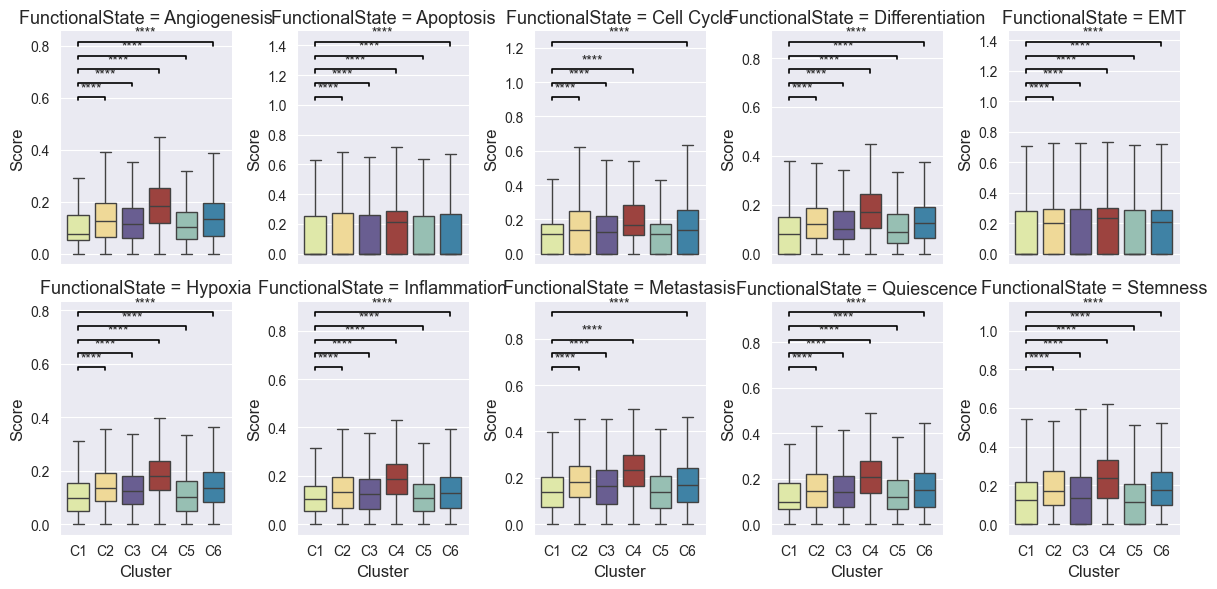

In [17]:

# === Prepare gene sets ===
geneset_df = pd.read_csv(data_path_main + "CancerSEA_OV/functional_geneset_list_df.csv")
geneset_df = geneset_df[geneset_df['Gene'].isin(adata_list[0].var_names)]

geneset_index_dict = {
    term: np.where(np.isin(adata_list[0].var_names,
                           geneset_df.loc[geneset_df['GeneSet'] == term, 'Gene']))[0]
    for term in np.unique(geneset_df['GeneSet'])
}

exp = adata_choose.X.toarray()
exp_norm = exp / (np.max(exp, axis=0) + 1e-8)

for term, idxs in geneset_index_dict.items():
    adata_choose.obs[f"{term}_score"] = (
        np.mean(exp_norm[:, idxs], axis=1) if len(idxs) > 0 else np.zeros(adata_choose.n_obs)
    )

# === Long data ===
functional_states = [
    'Angiogenesis_score', 'Apoptosis_score', 'Cell Cycle_score',
    'Differentiation_score', 'EMT_score', 'Hypoxia_score',
    'Inflammation_score', 'Metastasis_score',
    'Quiescence_score', 'Stemness_score'
]

df_long = adata_choose.obs.melt(
    id_vars=['MI_louvain'],
    value_vars=functional_states,
    var_name="FunctionalState",
    value_name="Score"
).dropna()

df_long["MI_louvain"] = df_long["MI_louvain"].astype(str)
df_long.to_csv(f"{file_savepath_main}/FunctionalState_scores_by_MI_louvain_long.csv", index=False)

# === Dynamic order ===
order = sorted(df_long["MI_louvain"].unique(), key=lambda x: int(x))
cluster_labels = [f"C{x}" for x in order]  # no +1

# === Color palette ===
base_colors = ["#e6f29f", "#fee089", "#645599", "#ac352f", "#90c6b6", "#2e87b6"]
palette = {order[i]: base_colors[i % len(base_colors)] for i in range(len(order))}

# === Plot ===
g = sns.catplot(
    data=df_long,
    x="MI_louvain", y="Score",
    col="FunctionalState", kind="box",
    order=order, showfliers=False,
    col_wrap=5, sharey=False,
    height=3, aspect=0.8,
    palette=palette
)

# === Significance helper ===
def p_to_star(p):
    return "****" if p < 1e-4 else "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else ""

def add_star(ax, x1, x2, y, pval):
    stars = p_to_star(pval)
    if stars:
        ax.plot([x1, x1, x2, x2], [y, y+0.02*y, y+0.02*y, y], lw=1.2, c="k")
        ax.text((x1+x2)/2, y+0.03*y, stars, ha="center", va="bottom", fontsize=10)

# === Add significance ===
for ax, fstate in zip(g.axes.flatten(), df_long["FunctionalState"].unique()):
    subdf = df_long[df_long["FunctionalState"] == fstate]
    clusters_here = [c for c in order if c in subdf["MI_louvain"].unique()]
    ref = clusters_here[0]
    ref_vals = subdf[subdf["MI_louvain"] == ref]["Score"]
    ymax = subdf["Score"].max()
    for i, other in enumerate(clusters_here[1:], start=1):
        other_vals = subdf[subdf["MI_louvain"] == other]["Score"]
        _, pval = ranksums(ref_vals, other_vals)
        add_star(ax, 0, i, ymax * (1.05 + 0.1*i), pval)

# === Final formatting ===
plt.draw()
for ax in g.axes.flatten():
    title = ax.get_title().replace("_score", "").replace("_", " ")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Cluster", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(cluster_labels, fontsize=10)  # e.g., C0, C1, C2 ...

plt.tight_layout()
plt.savefig(f"{file_savepath_main}/FunctionalState_boxplot_MILouvain.png", dpi=300)
plt.show()
plt.close()


### Barplot of cluster proportions of phenotype

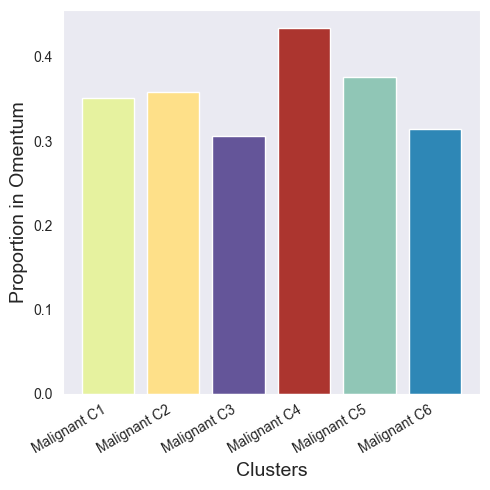

In [18]:
# Barplot of Omentum proportion by cluster

# Extract relevant columns
df = adata_choose.obs[['MI_louvain', 'sites_binary_x']].copy()

# Compute the proportion of Omentum cells in each cluster
prop_table = (
    df.groupby('MI_louvain')['sites_binary_x']
      .value_counts(normalize=True)
      .rename("proportion")
      .reset_index()
)

# Filter for Omentum only
prop_oment = prop_table[prop_table['sites_binary_x'] == 'Omentum']

# Order clusters to match UMAP color palette
order = ['1', '2', '3', '4', '5', '6']
colors = ["#e6f29f", "#fee089", "#645599", "#ac352f", "#90c6b6", "#2e87b6"]

prop_oment = prop_oment.set_index('MI_louvain').loc[order].reset_index()

# Rename clusters (C1–C6)
prop_oment['ClusterName'] = [f"Malignant C{int(c)}" for c in prop_oment['MI_louvain']]

# Plot
plt.close()
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(prop_oment['ClusterName'], prop_oment['proportion'], color=colors)

ax.set_ylabel("Proportion in Omentum", fontsize=14)
ax.set_xlabel("Clusters", fontsize=14)
ax.grid(False)
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig(
    f"{file_savepath_main}Barplot_Omentum_proportion_by_MI_louvain.png",
    dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()
plt.close()


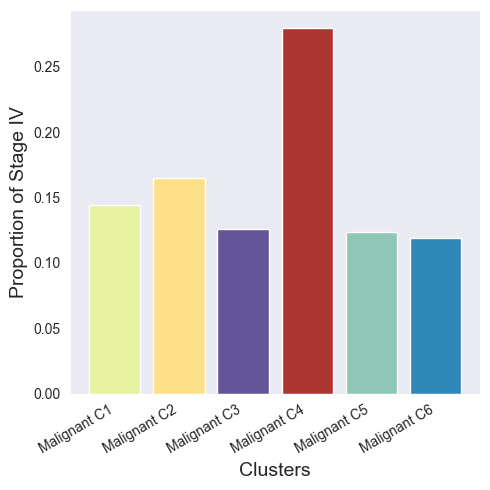

In [19]:
# Barplot of Stage IV proportion by cluster

# Extract relevant columns
df = adata_choose.obs[['MI_louvain', 'stage']].copy()

# Compute the proportion of Stage IV cells in each cluster
prop_table = (
    df.groupby('MI_louvain')['stage']
      .value_counts(normalize=True)
      .rename("proportion")
      .reset_index()
)

# Filter for Stage IV only
prop_stage4 = prop_table[prop_table['stage'] == 'IV']

# Order clusters to match UMAP color palette
order = ['1', '2', '3', '4', '5', '6']
colors = ["#e6f29f", "#fee089", "#645599", "#ac352f", "#90c6b6", "#2e87b6"]

prop_stage4 = prop_stage4.set_index('MI_louvain').loc[order].reset_index()

# Rename clusters (C1–C6)
prop_stage4['ClusterName'] = [f"Malignant C{int(c)}" for c in prop_stage4['MI_louvain']]

# Plot
plt.close()
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(prop_stage4['ClusterName'], prop_stage4['proportion'], color=colors)

ax.set_ylabel("Proportion of Stage IV", fontsize=14)
ax.set_xlabel("Clusters", fontsize=14)
ax.grid(False)
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig(
    f"{file_savepath_main}Barplot_StageIV_proportion_by_MI_louvain.png",
    dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()
plt.close()


### KEGG pathway enrichment analysis of cluster-specific upregulated genes

In [20]:
import gseapy as gp

In [21]:
# ==============================================================
# Step 1. Identify top up/down-regulated marker genes per cluster
# ==============================================================

adata_use = adata_choose.copy()
sc.tl.rank_genes_groups(adata_use, groupby='MI_louvain', method='wilcoxon')

up_genes_per_cluster, down_genes_per_cluster = {}, {}
groups = adata_use.uns['rank_genes_groups']['names'].dtype.names

for group in groups:
    df = sc.get.rank_genes_groups_df(adata_use, group=group)

    # Up-regulated genes
    df_up = df[(df['logfoldchanges'] > 0.5) & (df['pvals_adj'] < 0.05)]
    df_up = df_up.sort_values(['pvals_adj', 'logfoldchanges'], ascending=[True, False]).head(100)
    up_genes_per_cluster[group] = df_up

    # Down-regulated genes
    df_down = df[(df['logfoldchanges'] < -0.5) & (df['pvals_adj'] < 0.05)]
    df_down = df_down.sort_values(['pvals_adj', 'logfoldchanges'], ascending=[True, True]).head(100)
    down_genes_per_cluster[group] = df_down

print("Up-regulated gene counts per cluster:",
      [len(v) for v in up_genes_per_cluster.values()])
print("Down-regulated gene counts per cluster:",
      [len(v) for v in down_genes_per_cluster.values()])

Up-regulated gene counts per cluster: [0, 22, 10, 100, 39, 100]
Down-regulated gene counts per cluster: [100, 3, 2, 1, 100, 1]


In [22]:
# ==============================================================
# Step 2. KEGG enrichment analysis for upregulated genes
# ==============================================================

organism = "hsa"  # 'hsa' for human, 'mmu' for mouse
gene_set = f"KEGG_2021_{'Human' if organism == 'hsa' else 'Mouse'}"
organism_label = 'Human' if organism == 'hsa' else 'Mouse'

kegg_results = {}
for cluster, df_up in up_genes_per_cluster.items():
    if 'names' not in df_up.columns or df_up.empty:
        continue

    enr = gp.enrichr(
        gene_list=df_up['names'].tolist(),
        gene_sets=gene_set,
        organism=organism_label,
        outdir=None,
        cutoff=0.05
    )
    result_df = enr.results.sort_values('Adjusted P-value', ascending=True)
    kegg_results[cluster] = result_df

print(f"KEGG enrichment completed for {len(kegg_results)} clusters.")



KEGG enrichment completed for 5 clusters.


In [23]:
# ==============================================================
# Step 3. Collect all KEGG terms across clusters
# ==============================================================

all_kegg_terms = sorted({term for df in kegg_results.values() if 'Term' in df.columns for term in df['Term']})
print(f"Total unique KEGG terms: {len(all_kegg_terms)}")
print(all_kegg_terms)


Total unique KEGG terms: 222
['ABC transporters', 'AGE-RAGE signaling pathway in diabetic complications', 'AMPK signaling pathway', 'Acute myeloid leukemia', 'Adherens junction', 'Adipocytokine signaling pathway', 'Adrenergic signaling in cardiomyocytes', 'African trypanosomiasis', 'Alcoholism', 'Aldosterone synthesis and secretion', 'Aldosterone-regulated sodium reabsorption', 'Allograft rejection', 'Alzheimer disease', 'Amoebiasis', 'Amphetamine addiction', 'Amyotrophic lateral sclerosis', 'Antigen processing and presentation', 'Apelin signaling pathway', 'Apoptosis', 'Arachidonic acid metabolism', 'Arrhythmogenic right ventricular cardiomyopathy', 'Asthma', 'Autoimmune thyroid disease', 'Autophagy', 'Axon guidance', 'B cell receptor signaling pathway', 'Bacterial invasion of epithelial cells', 'Basal cell carcinoma', 'Base excision repair', 'Bile secretion', 'Bladder cancer', 'Breast cancer', 'C-type lectin receptor signaling pathway', 'Calcium signaling pathway', 'Cardiac muscle co

In [24]:
# ==============================================================
# Step 4. Build -log10(FDR) matrix for selected KEGG pathways
# ==============================================================

selected_terms = [
    "HIF-1 signaling pathway",
    "PD-L1 expression and PD-1 checkpoint pathway in cancer",
    "PI3K-Akt signaling pathway",
    "ECM-receptor interaction",
    "Antigen processing and presentation",
    "Cell adhesion molecules"
]

clusters = list(up_genes_per_cluster.keys())
neglogp_matrix = pd.DataFrame(0.0, index=clusters, columns=selected_terms)

for cluster in clusters:
    if cluster not in kegg_results:
        continue
    df = kegg_results[cluster]
    for term in selected_terms:
        row = df.loc[df['Term'] == term, 'Adjusted P-value']
        if not row.empty:
            pval = max(row.iloc[0], 1e-300)
            neglogp_matrix.loc[cluster, term] = -np.log10(pval)

neglogp_matrix = neglogp_matrix.astype(np.float32)
neglogp_matrix_z = (neglogp_matrix - neglogp_matrix.mean()) / neglogp_matrix.std(ddof=0)


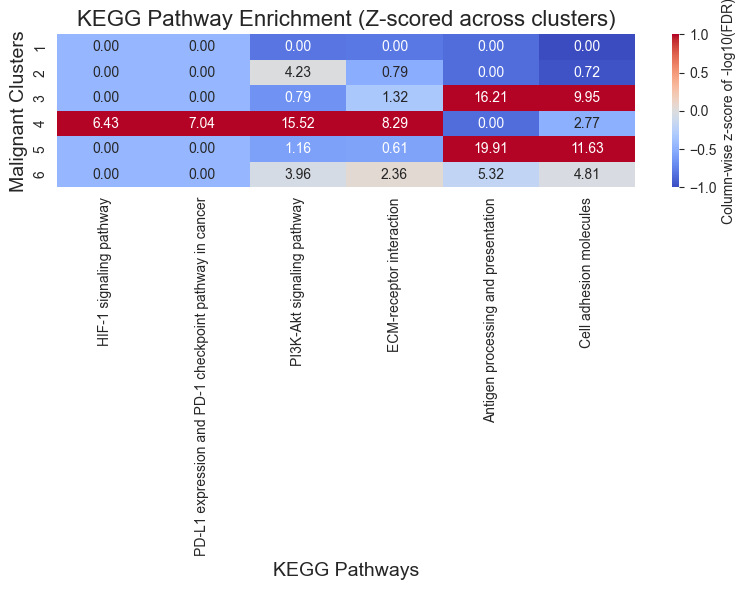

In [25]:
# ==============================================================
# Step 5. Plot z-scored heatmap (annotated with original values)
# ==============================================================

plt.close()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    neglogp_matrix_z,
    annot=neglogp_matrix.round(2),
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Column-wise z-score of -log10(FDR)'},
    ax=ax
)
ax.set_xlabel("KEGG Pathways", fontsize=14)
ax.set_ylabel("Malignant Clusters", fontsize=14)
plt.title("KEGG Pathway Enrichment (Z-scored across clusters)", fontsize=16)
plt.tight_layout()

plt.savefig(
    f"{file_savepath_main}KEGG_Enrichment_Heatmap_Malignant_Clusters_Zscore.png",
    dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()
plt.close()

### Obtain the mean sending/ receiving meta-interaction levels per malignant cluster

In [26]:
file_savepath_main

'D:/CellFlowMap/HGSC/Results/V1\\SpiderNet_Result_Mode_cell_class_selfsetdim15\\'

In [27]:
# ==============================================================
# Step 1. Calculate sending/receiving MI levels per cell
# ==============================================================
Factor_envir_list = pd.read_pickle(file_savepath_main + "Factor_envir_list.pkl")
adata_copy = sc.read_h5ad(file_savepath_main + "adata_all.h5ad")
SpiderNet_data_pyg_list = pd.read_pickle(file_savepath_main + 'SpiderNet_data_pyg_list.pkl')
cellclass_unique = np.unique(adata_copy.obs['cell.types'])